## Data loading and analysis setup 


In [ ]:

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import geodatasets
import requests
import zipfile
import os

# The purpose of this cell is to load the processed data from the previous notebook.
# This is necessary because this notebook is intended to be run independently of the first one.
# It ensures that the 'df_f' DataFrame is available for the analysis that follows.

# Define the path to the processed data file
# It's constructed to be relative to the current working directory of the notebook
try:
    processed_path = (Path.cwd() / ".." / "Data_Processed" / "ACLED_Kyrgyzstan_Tajikistan_2018-2025_processed.csv").resolve()
    df_f = pd.read_csv(processed_path)
except FileNotFoundError:
    # Fallback for a different directory structure
    processed_path = (Path.cwd() / "Data_Processed" / "ACLED_Kyrgyzstan_Tajikistan_2017-2025_processed.csv").resolve()
    df_f = pd.read_csv(processed_path)


# Convert 'event_date' to datetime objects for proper filtering and analysis
df_f['event_date'] = pd.to_datetime(df_f['event_date'])
df_f.head()

,event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,...,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp,event_month
0,TJK58,2019-09-29,2019,3,Strategic developments,Strategic developments,Arrests,Police Forces of Tajikistan (1994-),NaN,State forces,...,40.1223,70.6272,2,Fergana News; Dialog,National-International,"As reported on 29 September, law enforcers of ...",0,NaN,1572006472,2019-09-01
1,TJK13,2018-07-15,2018,3,Political violence,Violence against civilians,Attack,Police Forces of Tajikistan (1994-),NaN,State forces,...,40.2811,69.6392,3,Kyrgyztoday,International,"In the summer of 2018, a man was arrested as p...",0,NaN,1618580363,2018-07-01
2,TJK30,2019-01-01,2019,2,Political violence,Violence against civilians,Attack,Police Forces of Tajikistan (1994-),NaN,State forces,...,39.3903,68.5392,1,Tajinfo.org,National,"In early January 2019, an elderly female resid...",0,NaN,1572006494,2019-01-01
3,KGZ320,2019-12-16,2019,1,Demonstrations,Protests,Peaceful protest,Protesters (Kyrgyzstan),NaN,Protesters,...,39.9507,70.5490,1,24Kg,National,"On 16 December 2019, 30-40 Kyrgyz villagers fr...",0,crowd size=30-40,1578945413,2019-12-01
4,KGZ340,2020-01-11,2020,1,Political violence,Riots,Mob violence,Rioters (Kyrgyzstan),NaN,Rioters,...,39.9507,70.5490,2,Kaktus Media; RFE/RL,National-International,"On 11 January 2020, rioters from Tajikistan th...",0,crowd size=unknown,1579540786,2020-01-01


### 1) Pre-2023 vs Post-2023 comparison

**Section objective**
This section evaluates whether the conflict profile changes after 2023 by comparing event composition and monthly trajectories.

**Charts generated in this section**
- **Chart A:** yearly pie charts of `event_type` composition plus normalized period comparison metrics.
- **Chart B:** monthly event-type trend lines with structural break markers.
- **Chart C:** interactive structural-break visualization with contextual annotations.

**Reproducibility requirements**
1. Run Cell 0 to load `df_f` from the processed dataset.
2. Ensure `event_date` is datetime and period labels are created (`Pre-2023`, `Post-2023`).
3. Execute chart cells in order so intermediate variables are available.

**What this section accomplishes**
It provides visual evidence for whether conflict dynamics shift from localized communal incidents toward more state-linked interactions after 2023.


#### A) Chart A: Yearly event-type composition 

**Objective**
Compare how the distribution of `event_type` changes between `Pre-2023` and `Post-2023` while accounting for unequal years of coverage.

**Data and method**
- Build yearly counts of `event_type` from `df_f`.
- Visualization of faceted pie charts (`px.pie`) for each year.
- In each pie facet title, `n` means the **total number of events recorded in that year**.
- Summary tables: period-level averages (`events/year`, `active event types/year`) and composition shifts in percentage points.

**How to reproduce**
Run the period/grouping cell first, then execute the plotting/summary cell directly below.

**What this chart accomplishes**
It separates composition changes from unequal period lengths and provides a fair pre/post comparison.


In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Build yearly event-type counts for pie charts and normalized comparisons.
df_chart = df_f.copy()
df_chart["event_date"] = pd.to_datetime(df_chart["event_date"], errors="coerce")
df_chart = df_chart.dropna(subset=["event_date", "event_type"])
df_chart["year"] = df_chart["event_date"].dt.year.astype(int)
df_chart["period"] = df_chart["year"].map(lambda y: "Pre-2023" if y < 2023 else "Post-2023")

yearly_event_type = (
    df_chart.groupby(["year", "event_type"], as_index=False)
    .size()
    .rename(columns={"size": "events"})
    .sort_values(["year", "events"], ascending=[True, False])
)

# Keep the chart focused on the six event types used in the analysis.
event_types = [
    "Battles",
    "Explosions/Remote violence",
    "Protests",
    "Riots",
    "Strategic developments",
    "Violence against civilians",
]
yearly_event_type = yearly_event_type[yearly_event_type["event_type"].isin(event_types)].copy()
yearly_event_type["period"] = yearly_event_type["year"].map(lambda y: "Pre-2023" if y < 2023 else "Post-2023")

yearly_totals = yearly_event_type.groupby("year", as_index=False)["events"].sum()
year_to_total = dict(zip(yearly_totals["year"], yearly_totals["events"]))

event_type_colors = {
    "Battles": "#d62728",
    "Explosions/Remote violence": "#ff7f0e",
    "Protests": "#f1c40f",
    "Riots": "#1f77b4",
    "Strategic developments": "#2ca02c",
    "Violence against civilians": "#9467bd",
}

def legend_name_for(event_type: str) -> str:
    """Legend display only (Plotly supports <br>); keeps long labels visible in horizontal legends."""
    if event_type == "Explosions/Remote violence":
        return "Explosions/<br>Remote violence"
    return event_type


def build_year_text(year_frame: pd.DataFrame, threshold: float = 5.0) -> list[str]:
    shares = (year_frame["events"] / year_frame["events"].sum() * 100).round(2)
    return [f"{share:.1f}%" if share >= threshold else "" for share in shares]

row_1_years = [2018, 2019, 2020]
row_2_years = [2021, 2022]
row_3_years = [2023, 2024, 2025]
year_groups = [row_1_years, row_2_years, row_3_years]
row_heights = [0.35, 0.35, 0.35, 0.01]

fig_year_pies = make_subplots(
    rows=4,
    cols=3,
    specs=[
        [{"type": "domain"}, {"type": "domain"}, {"type": "domain"}],
        [{"type": "domain"}, {"type": "domain"}, {"type": "domain"}],
        [{"type": "domain"}, {"type": "domain"}, {"type": "domain"}],
        [{"type": "xy", "colspan": 3}, None, None],
    ],
    row_heights=row_heights,
    column_widths=[0.33, 0.34, 0.33],
    vertical_spacing=0.09,
    horizontal_spacing=0.04,
    subplot_titles=[
        "2018",
        "2019",
        "2020",
        "2021",
        "2022",
        "",
        "2023",
        "2024",
        "2025",
        "",
    ],
)

for row_index, years_in_row in enumerate(year_groups, start=1):
    for col_index, year in enumerate(years_in_row, start=1):
        year_frame = yearly_event_type.loc[yearly_event_type["year"] == year].copy()
        if year_frame.empty:
            continue

        year_frame = year_frame.sort_values("events", ascending=False).reset_index(drop=True)
        total_events = int(year_to_total.get(year, 0))
        visible_text = build_year_text(year_frame, threshold=6.0)
        colors = [event_type_colors[event_type] for event_type in year_frame["event_type"]]

        fig_year_pies.add_trace(
            go.Pie(
                labels=year_frame["event_type"],
                values=year_frame["events"],
                sort=False,
                direction="clockwise",
                marker=dict(colors=colors, line=dict(color="#ffffff", width=1.4)),
                text=visible_text,
                texttemplate="%{text}",
                textposition="inside",
                insidetextorientation="radial",
                textfont=dict(size=10, color="#111111"),
                hole=0.0,
                hovertemplate=(
                    f"Year: {year}<br>"
                    "Event type: %{label}<br>"
                    "Events: %{value}<br>"
                    f"Year total (n): {total_events}<br>"
                    "Share: %{percent:.2%}<extra></extra>"
                ),
                showlegend=False,
            ),
            row=row_index,
            col=col_index,
        )


# Six legend entries (scatter cannot sit on domain/pie axes; attach to hidden xy row 4).
for legend_event_type in event_types:
    fig_year_pies.add_trace(
        go.Scatter(
            x=[0],
            y=[0],
            mode="markers",
            marker=dict(size=11, color=event_type_colors[legend_event_type], symbol="square"),
            name=legend_name_for(legend_event_type),
            visible="legendonly",
            showlegend=True,
        ),
        row=4,
        col=1,
    )

# Hide the intentionally blank slot in the middle row.
fig_year_pies.update_xaxes(visible=False, row=2, col=3)
fig_year_pies.update_yaxes(visible=False, row=2, col=3)
# Hide the legend-only subplot (no plotted data appears there).
fig_year_pies.update_xaxes(visible=False, row=4, col=1)
fig_year_pies.update_yaxes(visible=False, row=4, col=1)

# Move year labels closer to the pies and include yearly totals.
year_lookup = {year: int(year_to_total.get(year, 0)) for year in range(2018, 2026)}
for annotation in fig_year_pies.layout.annotations:
    if annotation.text and annotation.text.isdigit():
        year = int(annotation.text)
        annotation.text = f"{year} (n={year_lookup.get(year, 0)})"
        annotation.font = dict(size=13, color="#1f2937")
        annotation.yshift = -4

fig_year_pies.update_layout(
    title=dict(
        text="Event-type distribution by year (2018-2025)",
        x=0.5,
        xanchor="center",
    ),
    template="plotly_white",
    height=1180,
    margin=dict(l=30, r=30, t=90, b=235),
    legend=dict(
        title="Event type",
        orientation="h",
        yanchor="top",
        y=-0.02,
        xanchor="center",
        x=0.5,
        font=dict(size=10),
        bgcolor="rgba(255,255,255,0.92)",
    ),
    uniformtext=dict(minsize=10, mode="hide"),
)

fig_year_pies.add_annotation(
    x=0.5,
    y=-0.2,
    xref="paper",
    yref="paper",
    showarrow=False,
    align="center",
    font=dict(size=11, color="#1f2937"),
    text="*n = yearly total events.",
)

fig_year_pies.show()

# 2) Period-level normalized comparison tables.
yearly_metrics = (
    yearly_event_type.groupby("year", as_index=False)
    .agg(
        total_events=("events", "sum"),
        active_event_types=("event_type", "nunique"),
    )
)

yearly_metrics = (
    yearly_event_type.groupby("year", as_index=False)
    .agg(
        total_events=("events", "sum"),
        active_event_types=("event_type", "nunique"),
        period=("period", "first"),
    )
)

period_summary = (
    yearly_metrics.groupby("period", as_index=False)
    .agg(
        years_covered=("year", "nunique"),
        total_events=("total_events", "sum"),
        avg_events_per_year=("total_events", "mean"),
        avg_active_event_types_per_year=("active_event_types", "mean"),
    )
)
period_summary[["avg_events_per_year", "avg_active_event_types_per_year"]] = period_summary[
    ["avg_events_per_year", "avg_active_event_types_per_year"]
].round(2)

period_event_share = (
    yearly_event_type.groupby(["period", "event_type"], as_index=False)["events"].sum()
)
period_event_share["share_pct"] = (
    period_event_share["events"]
    / period_event_share.groupby("period")["events"].transform("sum")
    * 100
).round(2)

share_comparison = (
    period_event_share.pivot(index="event_type", columns="period", values="share_pct")
    .fillna(0)
    .reset_index()
)
share_comparison["change_pp_post_minus_pre"] = (
    share_comparison.get("Post-2023", 0) - share_comparison.get("Pre-2023", 0)
).round(2)

display(period_summary)
print("Event-type share change in percentage points (Post - Pre):")
display(share_comparison.sort_values("change_pp_post_minus_pre", ascending=False))

,period,years_covered,total_events,avg_events_per_year,avg_active_event_types_per_year
0,Post-2023,3,17,5.67,2.33
1,Pre-2023,5,299,59.80,5.20


Event-type share change in percentage points (Post - Pre):


period,event_type,Post-2023,Pre-2023,change_pp_post_minus_pre
2,Protests,58.82,42.14,16.68
1,Explosions/Remote violence,5.88,3.01,2.87
4,Strategic developments,11.76,9.03,2.73
3,Riots,11.76,17.73,-5.97
5,Violence against civilians,5.88,12.04,-6.16
0,Battles,5.88,16.05,-10.17


## B) Chart B: Structural breaks

**Objective**
Identify temporal breakpoints and cluster patterns in monthly conflict activity from 2018 to 2025.

**Chart B (static monthly trend lines)**
- Plots monthly counts by `event_type` using Matplotlib.
- Adds break markers to separate regimes and support pre/post-break comparison.

**How to reproduce**
1. Convert and clean dates in `df_f`.
2. Generate monthly event-type counts.
3. Run the static trend chart cell, then the interactive structural-break cell.

**What thid chart accomplish**
To show conflict intensity was much higher before 2023 and what the major peaks in 2021 and 2022 signal escalation phases. The chart suggests a transition from open conflict to relative calm after 2023.


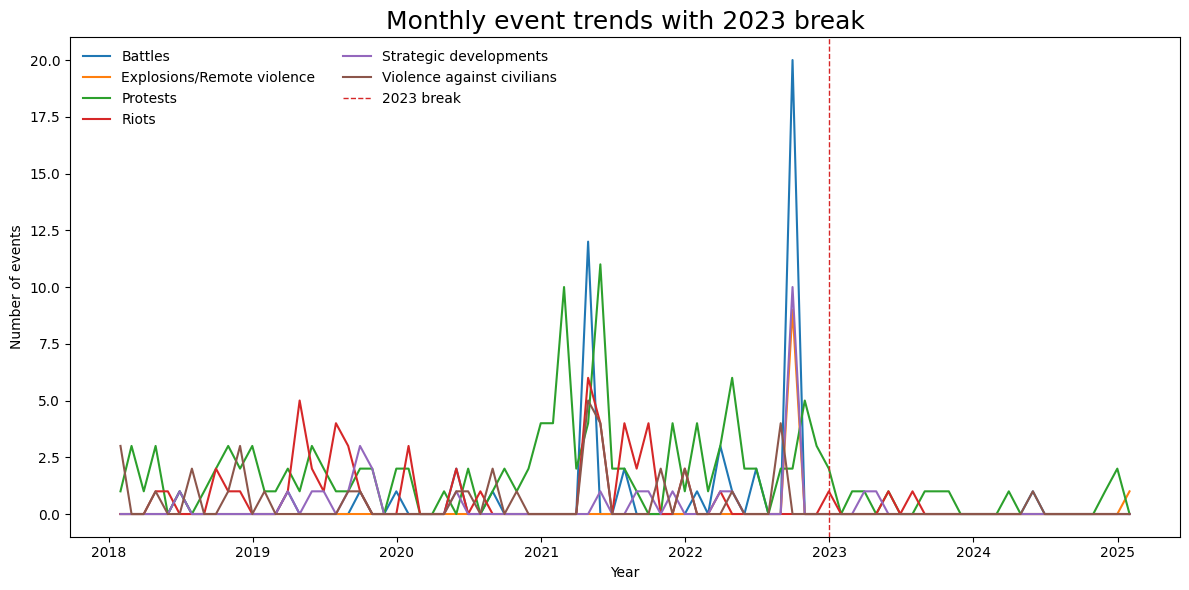

Interactive chart for Monthly event trends , Years: 2018 to 2025 (count=8)


In [ ]:
# prep 
df_f["event_date"] = pd.to_datetime(df_f["event_date"], errors="coerce")
df_plot = df_f.dropna(subset=["event_date", "event_type"]).copy()
event_types = sorted(df_plot["event_type"].unique())

# monthly (month-end) counts by event type
monthly_counts = (
    df_plot.set_index("event_date")
    .groupby("event_type")
    .resample("ME")   # <- changed from "M"
    .size()
    .unstack(level=0, fill_value=0)
)

monthly_counts = monthly_counts.reindex(columns=event_types, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))

for event_type in event_types:
    ax.plot(monthly_counts.index, monthly_counts[event_type], label=event_type)

ax.axvline(
    pd.Timestamp("2023-01-01"),
    color="#d62728",
    linestyle="--",
    linewidth=1,
    label="2023 break"
)
ax.set_title("Monthly event trends with 2023 break", fontsize=18)
ax.set_xlabel("Year")
ax.set_ylabel("Number of events")
ax.legend(ncol=2, frameon=False)

plt.tight_layout()
plt.show()

# Interactive version with year slider and spike hover details
import plotly.graph_objects as go
import numpy as np

interactive_df = df_plot.copy()
interactive_df["year"] = interactive_df["event_date"].dt.year.astype("Int64")
interactive_df = interactive_df.dropna(subset=["year"]).copy()
interactive_df["year"] = interactive_df["year"].astype(int)
interactive_df["year_month"] = interactive_df["event_date"].dt.to_period("M").dt.to_timestamp()
interactive_df["year_month_label"] = interactive_df["year_month"].dt.strftime("%Y-%m")
interactive_df["fatalities"] = pd.to_numeric(interactive_df.get("fatalities", 0), errors="coerce").fillna(0)

years = sorted(interactive_df["year"].unique().tolist())
event_types = sorted(interactive_df["event_type"].dropna().unique().tolist())

print(f"Interactive chart for Monthly event trends , Years: {years[0]} to {years[-1]} (count={len(years)})")

monthly_counts_long = (
    interactive_df.groupby(["year", "year_month", "event_type"]) 
    .size()
    .rename("events")
    .reset_index()
)

meta_cols = ["year", "year_month", "event_type"]
conflict_col = next((c for c in ["sub_event_type", "disorder_type", "event_type"] if c in interactive_df.columns), "event_type")
side1_col = next((c for c in ["actor1", "assoc_actor_1", "side_a"] if c in interactive_df.columns), None)
side2_col = next((c for c in ["actor2", "assoc_actor_2", "side_b"] if c in interactive_df.columns), None)
death1_col = next((c for c in ["actor1_deaths", "side_a_deaths", "deaths_a", "fatalities_actor1"] if c in interactive_df.columns), None)
death2_col = next((c for c in ["actor2_deaths", "side_b_deaths", "deaths_b", "fatalities_actor2"] if c in interactive_df.columns), None)

idx = interactive_df.groupby(meta_cols)["fatalities"].idxmax()
hover_meta = interactive_df.loc[idx, meta_cols].copy()
hover_meta["conflict_name"] = interactive_df.loc[idx, conflict_col].fillna("N/A").values
hover_meta["side_1"] = interactive_df.loc[idx, side1_col].fillna("N/A").values if side1_col else "N/A"
hover_meta["side_2"] = interactive_df.loc[idx, side2_col].fillna("N/A").values if side2_col else "N/A"
hover_meta["side_1_deaths"] = (
    pd.to_numeric(interactive_df.loc[idx, death1_col], errors="coerce").fillna(0).astype(int).astype(str).values
    if death1_col else "N/A"
)
hover_meta["side_2_deaths"] = (
    pd.to_numeric(interactive_df.loc[idx, death2_col], errors="coerce").fillna(0).astype(int).astype(str).values
    if death2_col else "N/A"
)

plot_long = monthly_counts_long.merge(hover_meta, on=["year", "year_month", "event_type"], how="left")
plot_long["year_month_label"] = plot_long["year_month"].dt.strftime("%Y-%m")

all_rows = []
for yr in years:
    month_index = pd.date_range(f"{yr}-01-01", f"{yr}-12-01", freq="MS")
    frame_grid = pd.MultiIndex.from_product([[yr], month_index, event_types], names=["year", "year_month", "event_type"]).to_frame(index=False)
    frame_data = frame_grid.merge(plot_long, on=["year", "year_month", "event_type"], how="left")
    frame_data["events"] = frame_data["events"].fillna(0)
    frame_data["conflict_name"] = frame_data["conflict_name"].fillna("N/A")
    frame_data["side_1"] = frame_data["side_1"].fillna("N/A")
    frame_data["side_2"] = frame_data["side_2"].fillna("N/A")
    frame_data["side_1_deaths"] = frame_data["side_1_deaths"].fillna("N/A")
    frame_data["side_2_deaths"] = frame_data["side_2_deaths"].fillna("N/A")
    frame_data["year_month_label"] = frame_data["year_month"].dt.strftime("%Y-%m")

    max_events = frame_data.groupby("event_type")["events"].transform("max")
    frame_data["spike_label"] = frame_data["events"].eq(max_events) & frame_data["events"].gt(0)
    all_rows.append(frame_data)

plot_slider_df = pd.concat(all_rows, ignore_index=True)

# Prepare bubble map: size by event count, position with anti-overlap jitter by event_type
# Use a non-linear scaling to better differentiate small event counts (1, 3, 5)
plot_slider_df["bubble_size"] = np.clip((plot_slider_df["events"] ** 0.7) * 12, 8, 50)

# Apply per-event-type offset to avoid overlapping on month axis
event_type_offset_days = {
    et: ((idx - (len(event_types) - 1) / 2) * (4 / max(len(event_types) - 1, 1)))
    for idx, et in enumerate(event_types)
}

# Assign colors by event_type
event_colors = {
    et: ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2"][i % 7]
    for i, et in enumerate(sorted(event_types))
}


def legend_name_for(event_type: str) -> str:
    """Legend label only; Plotly treats <br> as a newline in legend text."""
    if event_type == "Explosions/Remote violence":
        return "Explosions/<br>Remote violence"
    return event_type


# Build bubble traces per year
def build_bubble_traces(yr: int):
    traces = []
    d_year = plot_slider_df.loc[plot_slider_df["year"] == yr].copy()
    
    for et in sorted(event_types):
        d = d_year.loc[d_year["event_type"] == et].sort_values("year_month").copy()
        if d.empty:
            continue
        
        # Apply month offset per event_type
        x_shifted = d["year_month"] + pd.to_timedelta(event_type_offset_days[et], unit="D")
        
        customdata = list(
            zip(
                d["events"],  # Actual event count for hover
                d["conflict_name"],
                d["side_1"],
                d["side_2"],
                d["side_1_deaths"],
                d["side_2_deaths"],
                d["year_month_label"],
                d["spike_label"].map(lambda v: "Peak" if v else "Normal")
            )
        )
        
        traces.append(
            go.Scatter(
                x=x_shifted,
                y=d["event_type"],
                mode="markers",
                name=et,
                showlegend=False,
                marker=dict(
                    size=d["bubble_size"],
                    color=event_colors[et],
                    opacity=0.6,
                    line=dict(width=1, color="white")
                ),
                customdata=customdata,
                hovertemplate=(
                    "<b>%{fullData.name}</b><br>"
                    "Month: %{customdata[6]}<br>"
                    "Events: %{customdata[0]:.0f}<br>"
                    "Status: %{customdata[7]}<br>"
                    "Conflict: %{customdata[1]}<br>"
                    "Side 1: %{customdata[2]}<br>"
                    "Side 2: %{customdata[3]}<br>"
                    "<extra></extra>"
                ),
            )
        )
    return traces

initial_year = years[0]
fig_interactive = go.Figure()

all_traces_by_year = {}
trace_range_by_year = {}
data_offset = 0
for yr in years:
    all_traces_by_year[yr] = build_bubble_traces(yr)
    n_yr = len(all_traces_by_year[yr])
    trace_range_by_year[yr] = (data_offset, data_offset + n_yr)
    data_offset += n_yr
    for trace in all_traces_by_year[yr]:
        trace.visible = yr == initial_year
        fig_interactive.add_trace(trace)

# Legend entries only from these traces (avoids duplicate names with year slider traces).
_event_order = sorted(event_types)
for rank, et in enumerate(_event_order):
    fig_interactive.add_trace(
        go.Scatter(
            x=[plot_slider_df["year_month"].min()],
            y=[et],
            mode="markers",
            name=legend_name_for(et),
            marker=dict(size=12, color=event_colors[et], opacity=0.85, line=dict(width=1, color="white")),
            hoverinfo="skip",
            showlegend=True,
            visible="legendonly",
            legendgroup=et,
            legendrank=rank,
        )
    )

n_total = len(fig_interactive.data)
n_legend = len(_event_order)
slider_steps = []
for yr in years:
    lo, hi = trace_range_by_year[yr]
    visible_mask = []
    for j in range(n_total - n_legend):
        visible_mask.append(True if lo <= j < hi else False)
    for _ in range(n_legend):
        visible_mask.append("legendonly")
    assert len(visible_mask) == n_total

    slider_steps.append(
        {
            "method": "update",
            "label": str(yr),
            "args": [{"visible": visible_mask}],
        }
    )

fig_interactive.update_layout(
    title=f"Monthly Event Trends Bubble Map (2018-2025)",
    xaxis_title="Month",
    yaxis_title="Event Type",
    legend_title="Event Type",
    xaxis={"tickformat": "%Y-%m"},
    height=600,
    hovermode="closest",
    plot_bgcolor="rgba(240,240,240,0.5)",
    sliders=[
        {
            "active": 0,
            "currentvalue": {"prefix": "Year: "},
            "pad": {"t": 40},
            "steps": slider_steps,
        }
    ],
    annotations=[
        dict(
            text="<i>Bubble size represents the number of events</i>",
            xref="paper",
            yref="paper",
            x=-0.25,
            y=-0.12,
            showarrow=False,
            font=dict(size=11, color="gray"),
            xanchor="left"
        )
    ]
)

fig_interactive.show()


In [ ]:
import importlib
import subprocess
import sys

import numpy as np


def ensure_package(package_name: str) -> None:
    try:
        importlib.import_module(package_name)
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


ensure_package("plotly")
ensure_package("nbformat")
ensure_package("ipython")

import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import HTML, display

# Prefer inline interactive rendering inside the notebook/editor.
pio.renderers.default = "notebook_connected"

start_date = pd.Timestamp("2018-01-01")
end_date = pd.Timestamp("2025-12-31")

analysis_df = df_f.loc[
    (df_f["event_date"] >= start_date) & (df_f["event_date"] <= end_date)
].copy()
analysis_df["event_month"] = analysis_df["event_date"].dt.to_period("M").dt.to_timestamp()

month_index = pd.date_range("2018-01-01", "2025-12-01", freq="MS")

monthly_events = (
    analysis_df.groupby("event_month")
    .size()
    .reindex(month_index, fill_value=0)
    .rename("events")
)

fatality_col = "fatalities" if "fatalities" in analysis_df.columns else None
if fatality_col:
    monthly_fatalities = (
        analysis_df.groupby("event_month")[fatality_col]
        .sum(min_count=1)
        .reindex(month_index, fill_value=0)
        .fillna(0)
        .astype(int)
        .rename("fatalities")
    )
else:
    monthly_fatalities = pd.Series(0, index=month_index, name="fatalities")

if "event_type" in analysis_df.columns:
    event_type_rank = (
        analysis_df.groupby(["event_month", "event_type"]).size().rename("n").reset_index()
    )
    dominant_event_type = (
        event_type_rank.sort_values(["event_month", "n", "event_type"], ascending=[True, False, True])
        .drop_duplicates("event_month")
        .set_index("event_month")["event_type"]
        .reindex(month_index)
        .fillna("No recorded event")
        .rename("dominant_event_type")
    )
else:
    dominant_event_type = pd.Series(
        "No recorded event", index=month_index, name="dominant_event_type"
    )


def classify_actor_type(actor_name: str) -> str:
    if pd.isna(actor_name):
        return "Unknown"

    actor = str(actor_name).lower()
    if any(
        k in actor
        for k in [
            "military forces",
            "armed forces",
            "state forces",
            "border guards",
            "police forces",
            "ministry of interior",
            "government",
        ]
    ):
        return "State forces"
    if any(k in actor for k in ["civilian", "residents", "villagers", "locals"]):
        return "Civilians"
    if any(k in actor for k in ["riot", "protest"]):
        return "Rioters/protesters"
    if any(k in actor for k in ["militia", "armed group"]):
        return "Armed groups"
    return "Other / mixed"


actor_cols = [c for c in ["actor1", "actor2"] if c in analysis_df.columns]
if actor_cols:
    actor_long = (
        analysis_df[["event_month"] + actor_cols]
        .melt(id_vars=["event_month"], value_vars=actor_cols, value_name="actor_name")
        .dropna(subset=["actor_name"])
)
    actor_long["actor_type"] = actor_long["actor_name"].map(classify_actor_type)

    actor_counts = (
        actor_long.groupby(["event_month", "actor_type"])
        .size()
        .rename("n")
        .reset_index()
        .sort_values(["event_month", "n", "actor_type"], ascending=[True, False, True])
    )

    top_actor_types = (
        actor_counts.groupby("event_month")
        .apply(lambda d: ", ".join(d["actor_type"].head(2)))
        .rename("main_actor_types")
        .reindex(month_index)
        .fillna("No actors recorded")
    )
else:
    top_actor_types = pd.Series("No actors recorded", index=month_index, name="main_actor_types")

plot_df = pd.concat([monthly_events, monthly_fatalities, dominant_event_type, top_actor_types], axis=1).reset_index()
plot_df = plot_df.rename(columns={"index": "event_month"})

cluster_meta = {
    1: {
        "name": "Cluster 1: Communal Resource Conflict (2018-2020)",
        "description": "Low-intensity/high-frequency civilian disputes;\nminimal fatalities; enclave-localized.",
        "color": "#2ca02c",
    },
    2: {
        "name": "Cluster 2: Militarized Interstate Escalation (2021-2022)",
        "description": "State-to-state clashes with heavy weapons/UAVs;\nhighest fatalities; geographically dispersed strikes.",
        "color": "#d62728",
    },
    3: {
        "name": "Cluster 3: Securitized Cold Peace (2023-2025)",
        "description": "Sharp decline in violence/fatalities;\nstrategic developments and border securitization dominate.",
        "color": "#1f77b4",
    },
}


def assign_cluster(month):
    if month < pd.Timestamp("2021-01-01"):
        return 1
    if month < pd.Timestamp("2023-01-01"):
        return 2
    return 3


plot_df["cluster_id"] = plot_df["event_month"].map(assign_cluster)
plot_df["cluster_name"] = plot_df["cluster_id"].map(lambda c: cluster_meta[c]["name"])
plot_df["cluster_description"] = plot_df["cluster_id"].map(lambda c: cluster_meta[c]["description"])

fig = go.Figure()

for cluster_id in [1, 2, 3]:
    chunk = plot_df.loc[plot_df["cluster_id"] == cluster_id].copy()
    meta = cluster_meta[cluster_id]
    customdata = np.column_stack(
        [
            chunk["cluster_name"],
            chunk["cluster_description"],
            chunk["dominant_event_type"],
            chunk["fatalities"],
            chunk["main_actor_types"],
        ]
    )

    fig.add_trace(
        go.Scatter(
            x=chunk["event_month"],
            y=chunk["events"],
            mode="lines+markers",
            name=meta["name"],
            line=dict(color=meta["color"], width=2.5),
            marker=dict(size=5, color=meta["color"]),
            customdata=customdata,
            hovertemplate=(
                "Month: %{x|%Y-%m}<br>"
                "Events: %{y}<br>"
                "<b>Cluster:</b> %{customdata[0]}<br>"
                "<b>Brief:</b> %{customdata[1]}<br>"
                "<b>Event type:</b> %{customdata[2]}<br>"
                "<b>Fatalities:</b> %{customdata[3]}<br>"
                "<b>Main actors:</b> %{customdata[4]}"
                "<extra></extra>"
            ),
        )
    )

# Structural break: January 2021 (militarization pivot)
fig.add_shape(
    type="line",
    x0=pd.Timestamp("2021-01-01"),
    x1=pd.Timestamp("2021-01-01"),
    y0=0,
    y1=1,
    xref="x",
    yref="paper",
    line=dict(color="#ff7f0e", width=2, dash="dash"),
)

# Structural break: January 2023 (demarcation/de-escalation pivot)
fig.add_shape(
    type="line",
    x0=pd.Timestamp("2023-01-01"),
    x1=pd.Timestamp("2023-01-01"),
    y0=0,
    y1=1,
    xref="x",
    yref="paper",
    line=dict(color="#9467bd", width=2, dash="dash"),
)

fig.add_annotation(
    x=pd.Timestamp("2020-03-01"),
    y=0.9,
    xref="x",
    yref="paper",
    text="Jan 2021: Militarization pivot",
    showarrow=False,
    font=dict(color="#ff7f0e", size=10),
    align="left",
    bgcolor="rgba(255,255,255,0.88)",
    bordercolor="#ff7f0e",
    borderwidth=1,
)

fig.add_annotation(
    x=pd.Timestamp("2024-04-10"),
    y=0.9,
    xref="x",
    yref="paper",
    text="Jan 2023: Demarcation / de-escalation pivot",
    showarrow=False,
    font=dict(color="#9467bd", size=10),
    align="left",
    bgcolor="rgba(255,255,255,0.88)",
    bordercolor="#9467bd",
    borderwidth=1,
)

fig.add_annotation(
    x=0,
    y=1.18,
    xref="paper",
    yref="paper",
    text="Zoom window:",
    showarrow=False,
    font=dict(size=10, color="#333333"),
    align="center",
)

fig.update_layout(
    title=dict(
        text="Kyrgyzstan-Tajikistan Border Conflict Dynamics (2018-2025)",
        x=0.5,
        xanchor="center",
        y=0.985,
        yanchor="top",
    ),
    xaxis_title="Time (month)",
    yaxis_title="Number of events",
    xaxis=dict(
        range=[pd.Timestamp("2018-01-01"), pd.Timestamp("2025-12-31")],
        rangeselector=dict(
            y=1.16,
            yanchor="bottom",
            x=0.12,
            xanchor="left",
            buttons=[
                dict(count=12, label="1y", step="month", stepmode="backward"),
                dict(count=24, label="2y", step="month", stepmode="backward"),
                dict(step="all", label="All"),
            ],
        ),
        rangeslider=dict(visible=True, thickness=0.09),
    ),
    legend_title="Conflict clusters",
    legend=dict(
        font=dict(size=9),
        title_font=dict(size=10),
        tracegroupgap=2,
        bgcolor="rgba(255,255,255,0.55)",
        orientation="v",
        x=0,
        xanchor="left",
        y=-0.58,
        yanchor="top",
    ),
    hovermode="closest",
    template="plotly_white",
    margin=dict(t=165, r=40, b=330, l=60),
    hoverlabel=dict(align="left", font=dict(size=10)),
    dragmode="pan",
    height=900,
 )

plot_config = {
    "displaylogo": False,
    "scrollZoom": False,
    "modeBarButtonsToRemove": ["select2d", "lasso2d", "toggleSpikelines"],
}

try:
    fig.show(config=plot_config)
except ValueError as exc:
    if "nbformat" in str(exc).lower():
        # Notebook-safe fallback: embed Plotly HTML directly in cell output.
        display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False, config=plot_config)))
    else:
        raise

## C) Chart C:conflict-cluster dynamics

**Objective**
Identify cluster patterns in monthly conflict activity from 2018 to 2025.

**Chart C (interactive structural-break chart)**
- Uses Plotly for annotated regimes, hover details, and clearer cluster interpretation.
- Highlights three conflict clusters and their timing relative to major break years.

**How to reproduce**
1. Convert and clean dates in `df_f`.
2. Generate monthly event-type counts.
3. Run the interactive structural-break cell.

**What this chart accomplish**
This chart explains how the conflict between Kyrgyzstan and Tajikistan changed over time (2018–2025) and highlights two major turning points. Going through both charts B and C show not only whether event volume changes, but also when major shifts occur and how conflict phases are grouped over time.


In [ ]:
from IPython.display import Markdown, display

display(Markdown("## Comparison: Pre-2023 vs. Post-2023"))
display(comparison_table)


## Comparison: Pre-2023 vs. Post-2023

,Feature,Pre-2023 Dynamics,Post-2023 Dynamics
0,Primary Actor,Local Civilians / Border Guards,Regular Army / State Officials
1,Event Type,Riots & Property Destruction,Strategic Developments & Patrols
2,Interaction,"Communal (17, 77)",State-to-State (11)
3,Resolution,Temporary Ceasefires,Formal Demarcation Mapping


The transition from 2017 (localized) to 2022 (state-led) to 2025 (institutionalized) indicates that while the violence has decreased post-2023, the militarized infrstructure of the border has become a permanent ficture of the landscape.

### 4) Mapping the 2021 and 2022 conflicts

**Objective**
Document where conflict events are geographically concentrated during 2021 dispute and 2022 border clashes respectively, also how escalation periods differ spatially.

**Data and method**
- Filters ACLED observations to the target years/windows.
- Cleans geographic coordinates and converts to geospatial layers.
- Uses map-based plotting to display event location and relative intensity.

**How to reproduce**
1. Confirm `event_date`, `latitude`, and `longitude` are valid in `df_f`.
2. Run the map-preparation cells that build GeoDataFrames.
3. Execute the plotting cells in sequence.

**What this section accomplishes**
It complements temporal charts by showing where the conflict is concentrated and whether escalation is spatially clustered.


In [ ]:
# Make sure event_date is datetime
df_f["event_date"] = pd.to_datetime(df_f["event_date"], errors="coerce")

# Build 2021 / 2022 clash datasets
# Prefer exact "notes" labels if available; fallback to year filter
if "notes" in df_f.columns:
    clash_2021 = df_f[df_f["notes"].astype(str).str.contains("2021 Dispute", na=False)].copy()
    clash_2022 = df_f[df_f["notes"].astype(str).str.contains("2022 Dispute", na=False)].copy()
else:
    clash_2021 = df_f[df_f["event_date"].dt.year == 2021].copy()
    clash_2022 = df_f[df_f["event_date"].dt.year == 2022].copy()

# Optional safety: keep rows with coordinates only
clash_2021 = clash_2021.dropna(subset=["longitude", "latitude"])
clash_2022 = clash_2022.dropna(subset=["longitude", "latitude"])
clash_2021_gdf = gpd.GeoDataFrame(
    clash_2021.copy(),
    geometry=gpd.points_from_xy(clash_2021["longitude"], clash_2021["latitude"]),
    crs="EPSG:4326"
)

clash_2021_gdf.head()

,event_date,date_str,year,quarter,month,event_month,country,admin1,event_type,actor1,actor2,fatalities,latitude,longitude,event_id_cnty,interaction,period,geometry
35,2021-02-04,2021-02-04,2021,1,2,2021-02-01,Kyrgyzstan,Batken,Protests,Protesters (Kyrgyzstan),Unknown,0,39.8961,69.3688,KGZ872,Protesters only,Pre-2023,POINT (69.3688 39.8961)
36,2021-02-01,2021-02-01,2021,1,2,2021-02-01,Kyrgyzstan,Batken,Protests,Protesters (Kyrgyzstan),Unknown,0,40.0639,70.8247,KGZ862,Protesters only,Pre-2023,POINT (70.8247 40.0639)
37,2021-02-05,2021-02-05,2021,1,2,2021-02-01,Kyrgyzstan,Batken,Protests,Protesters (Kyrgyzstan),Unknown,0,40.0639,70.8247,KGZ876,Protesters only,Pre-2023,POINT (70.8247 40.0639)
38,2021-02-11,2021-02-11,2021,1,2,2021-02-01,Kyrgyzstan,Batken,Protests,Protesters (Kyrgyzstan),Unknown,0,39.8789,70.5192,KGZ890,Protesters only,Pre-2023,POINT (70.5192 39.8789)
39,2021-02-10,2021-02-10,2021,1,2,2021-02-01,Kyrgyzstan,Batken,Protests,Protesters (Kyrgyzstan),Unknown,0,40.0639,70.8247,KGZ888,Protesters only,Pre-2023,POINT (70.8247 40.0639)


In [ ]:
clash_2022_gdf = gpd.GeoDataFrame(
    clash_2022.copy(),
    geometry=gpd.points_from_xy(clash_2022["longitude"], clash_2022["latitude"]),
    crs="EPSG:4326"
)

clash_2022_gdf.head()

,event_date,date_str,year,quarter,month,event_month,country,admin1,event_type,actor1,actor2,fatalities,latitude,longitude,event_id_cnty,interaction,period,geometry
114,2022-01-18,2022-01-18,2022,1,1,2022-01-01,Kyrgyzstan,Batken,Protests,Protesters (Kyrgyzstan),Unknown,0,40.0639,70.8247,KGZ1409,Protesters only,Pre-2023,POINT (70.8247 40.0639)
115,2022-01-23,2022-01-23,2022,1,1,2022-01-01,Kyrgyzstan,Batken,Protests,Protesters (Kyrgyzstan),Unknown,0,40.0304,69.8174,KGZ1417,Protesters only,Pre-2023,POINT (69.8174 40.0304)
116,2022-01-27,2022-01-27,2022,1,1,2022-01-01,Tajikistan,Sughd,Battles,Military Forces of Tajikistan (1994-) Border S...,Police Forces of Kyrgyzstan (2021-) Kyrgyz Fro...,2,39.9779,70.5710,TJK122,State forces-External/Other forces,Pre-2023,POINT (70.571 39.9779)
117,2022-01-26,2022-01-26,2022,1,1,2022-01-01,Kyrgyzstan,Batken,Protests,Protesters (Kyrgyzstan),Unknown,0,39.9507,70.5490,KGZ1427,Protesters only,Pre-2023,POINT (70.549 39.9507)
118,2022-01-24,2022-01-24,2022,1,1,2022-01-01,Kyrgyzstan,Batken,Protests,Protesters (Kyrgyzstan),Unknown,0,40.3079,71.3438,KGZ1422,Protesters only,Pre-2023,POINT (71.3438 40.3079)


In [ ]:
# Load a higher-resolution world map for smoother boundaries
url = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip"
world = gpd.read_file(url)

# Data file of the world map
world

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,0,2,Indonesia,IDN,0,2,Sovereign country,1,Indonesia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4..."
1,Admin-0 country,0,3,Malaysia,MYS,0,2,Sovereign country,1,Malaysia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4..."
2,Admin-0 country,0,2,Chile,CHL,0,2,Sovereign country,1,Chile,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."
3,Admin-0 country,0,3,Bolivia,BOL,0,2,Sovereign country,1,Bolivia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5..."
4,Admin-0 country,0,2,Peru,PER,0,2,Sovereign country,1,Peru,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,Admin-0 country,0,4,China,CH1,1,2,Country,1,Macao S.A.R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((113.5586 22.16303, 113.56943 2..."
254,Admin-0 country,6,5,Australia,AU1,1,2,Dependency,1,Ashmore and Cartier Islands,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((123.59702 -12.42832, 123.59775 -12.4..."
255,Admin-0 country,6,8,Bajo Nuevo Bank (Petrel Is.),BJN,0,2,Indeterminate,1,Bajo Nuevo Bank (Petrel Is.),...,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,"POLYGON ((-79.98929 15.79495, -79.98782 15.796..."
256,Admin-0 country,6,5,Serranilla Bank,SER,0,2,Indeterminate,1,Serranilla Bank,...,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,"POLYGON ((-78.63707 15.86209, -78.64041 15.864..."


In [ ]:
import geodatasets
print(dir(geodatasets.data.naturalearth))

['cities', 'lakes', 'land']



The interactive visual evidence for conflict timing, intensity, and spatial concentration using the 2018-2025 dataset.

**Charts in this section**
- Interactive geospatial event map.
- Dual-axis monthly timeline (events and fatalities).
- Escalation-window map for high-intensity periods.

**Reproducibility checklist**
1. Keep `event_date` in datetime format before any grouping/filtering.
2. Execute cells top-to-bottom to preserve derived tables and helper variables.
3. Install missing dependencies from the setup/import cells if needed.

**What this section accomplishes**
It allows readers to inspect patterns interactively rather than relying only on static summaries.


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import plotly.graph_objects as go

# ---- 1) Build event set for all 2021 and 2022 ACLED events ----
if not pd.api.types.is_datetime64_any_dtype(df_f["event_date"]):
    df_f["event_date"] = pd.to_datetime(df_f["event_date"], errors="coerce")

# Keep all events in 2021 and 2022 (not only escalation windows).
mask_2021 = df_f["event_date"].dt.year == 2021
mask_2022 = df_f["event_date"].dt.year == 2022

# Escalation windows for contextual highlighting in hover and styling.
escalation_2021_start = pd.Timestamp("2021-04-28")
escalation_2021_end = pd.Timestamp("2021-05-01")
escalation_2022_start = pd.Timestamp("2022-01-27")
escalation_2022_end = pd.Timestamp("2022-09-20")
peak_2022_start = pd.Timestamp("2022-09-14")
peak_2022_end = pd.Timestamp("2022-09-20")

clashes_map = df_f[mask_2021 | mask_2022].copy()
clashes_map = clashes_map.dropna(subset=["latitude", "longitude"]).copy()
clashes_map["fatalities"] = pd.to_numeric(clashes_map.get("fatalities", 0), errors="coerce").fillna(0)

clashes_map["period"] = np.where(clashes_map["event_date"].dt.year == 2021, "2021 Dispute", "2022 Dispute")
clashes_map["in_escalation_window"] = (
    (clashes_map["period"] == "2021 Dispute")
    & clashes_map["event_date"].between(escalation_2021_start, escalation_2021_end)
) | (
    (clashes_map["period"] == "2022 Dispute")
    & clashes_map["event_date"].between(escalation_2022_start, escalation_2022_end)
)
clashes_map["peak_sep_2022"] = (
    (clashes_map["period"] == "2022 Dispute")
    & clashes_map["event_date"].between(peak_2022_start, peak_2022_end)
)

# Add 1 to include zero-fatality events and use log transform to reduce skew.
clashes_map["fatalities_for_visualization"] = clashes_map["fatalities"] + 1
clashes_map["bubble_size"] = np.clip(np.log(clashes_map["fatalities_for_visualization"]) * 13 + 7, 7, 25)

# Stronger anti-overlap jitter for duplicate coordinates.
dup_rank = clashes_map.groupby(["latitude", "longitude"]).cumcount()
dup_total = clashes_map.groupby(["latitude", "longitude"])["latitude"].transform("count")
angles = (dup_rank * 2.39996323) % (2 * np.pi)
radius = np.where(dup_total > 1, 0.015 + np.sqrt(dup_rank) * 0.012, 0.0)
clashes_map["lat_plot"] = clashes_map["latitude"] + radius * np.sin(angles)
clashes_map["lon_plot"] = clashes_map["longitude"] + radius * np.cos(angles) / np.cos(np.deg2rad(clashes_map["latitude"].clip(-70, 70)))

location_candidates = ["location", "admin2", "admin1"]
location_col = next((c for c in location_candidates if c in clashes_map.columns), None)
actor1_col = "actor1" if "actor1" in clashes_map.columns else None
actor2_col = "actor2" if "actor2" in clashes_map.columns else None

clashes_map["location_label"] = clashes_map[location_col].astype(str) if location_col else "Unknown location"
clashes_map["location_label"] = clashes_map["location_label"].replace("nan", "Unknown location")
clashes_map["actor1_label"] = clashes_map[actor1_col].astype(str) if actor1_col else "Unknown"
clashes_map["actor2_label"] = clashes_map[actor2_col].astype(str) if actor2_col else "Unknown"
clashes_map["actor1_label"] = clashes_map["actor1_label"].replace("nan", "Unknown")
clashes_map["actor2_label"] = clashes_map["actor2_label"].replace("nan", "Unknown")

clashes_map["hover_text"] = clashes_map.apply(
    lambda r: "<br>".join(
        [
            f"<b>{r['period']}</b>",
            f"Location: {r['location_label']}",
            f"Event date: {r['event_date'].strftime('%Y-%m-%d') if pd.notna(r['event_date']) else 'Unknown'}",
            f"Actor 1: {r['actor1_label']}",
            f"Actor 2: {r['actor2_label']}",
            f"Fatalities: {int(r['fatalities'])}",
            "Peak phase: 14-20 Sep 2022" if r["peak_sep_2022"] else "",
        ]
    ).replace("<br><br>", "<br>").rstrip("<br>"),
    axis=1,
)

# ---- 2) Build regional map with highlighted countries ----
hires_url = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip"
world = gpd.read_file(hires_url)

regional_set = ["Kazakhstan", "Kyrgyzstan", "Tajikistan", "Uzbekistan", "Turkmenistan", "Afghanistan", "China"]
highlight_set = ["Kyrgyzstan", "Tajikistan", "Uzbekistan"]

regional = world[world["NAME"].isin(regional_set)].copy()
highlight = regional[regional["NAME"].isin(highlight_set)].copy()
pale_neighbors = regional[~regional["NAME"].isin(highlight_set)].copy()

country_colors = {
    "Kyrgyzstan": "#D6E8CF",
    "Tajikistan": "#F9DEC8",
    "Uzbekistan": "#D7E6F7",
}

fig = go.Figure()

if not pale_neighbors.empty:
    fig.add_trace(
        go.Choroplethmapbox(
            geojson=pale_neighbors.__geo_interface__,
            locations=pale_neighbors["NAME"],
            z=[1] * len(pale_neighbors),
            featureidkey="properties.NAME",
            colorscale=[[0, "#F3F4F6"], [1, "#F3F4F6"]],
            marker_line_color="#C9CED6",
            marker_line_width=1.0,
            showscale=False,
            name="Other regional countries",
            showlegend=False,
            hovertemplate="%{location}<extra></extra>",
        )
    )

for country in highlight_set:
    cdf = highlight[highlight["NAME"] == country]
    fig.add_trace(
        go.Choroplethmapbox(
            geojson=cdf.__geo_interface__,
            locations=cdf["NAME"],
            z=[1] * len(cdf),
            featureidkey="properties.NAME",
            colorscale=[[0, country_colors[country]], [1, country_colors[country]]],
            marker_line_color="#4C566A",
            marker_line_width=1.4,
            showscale=False,
            name=country,
            legendgroup="countries",
            legendgrouptitle_text="Countries" if country == "Kyrgyzstan" else None,
            showlegend=True,
            hovertemplate="%{location}<extra></extra>",
        )
    )

# ---- 3) Draw three conflict hotspot outlines ----
def make_circle(center_lat, center_lon, radius_km, n=220):
    theta = np.linspace(0, 2 * np.pi, n)
    lat = center_lat + (radius_km / 111.32) * np.sin(theta)
    lon = center_lon + (radius_km / (111.32 * np.cos(np.deg2rad(center_lat)))) * np.cos(theta)
    return lat, lon


hotspot_zones = [
    {
        "name": "Hotspot 1: Core border clashes (highest concentration)",
        "center": (39.95, 70.55),
        "radius_km": 18,
        "color": "#0EA5E9",
        "width": 3.2,
    },
    {
        "name": "Hotspot 2: Western villages corridor (repeated incidents)",
        "center": (40.13, 69.76),
        "radius_km": 16,
        "color": "#F97316",
        "width": 2.9,
    },
    {
        "name": "Hotspot 3: Adjacent border cluster (near core hotspot)",
        "center": (40.08, 70.76),
        "radius_km": 14,
        "color": "#A855F7",
        "width": 2.8,
    },
]

for i, z in enumerate(hotspot_zones):
    z_lat, z_lon = make_circle(z["center"][0], z["center"][1], z["radius_km"])
    fig.add_trace(
        go.Scattermapbox(
            lon=z_lon,
            lat=z_lat,
            mode="lines",
            line=dict(color=z["color"], width=z["width"]),
            name=z["name"],
            legendgroup="zone",
            legendgrouptitle_text="Conflict hotspot zones" if i == 0 else None,
            showlegend=True,
            hovertemplate=f"{z['name']}<extra></extra>",
        )
    )

# ---- 4) Event markers from ACLED ----
period_colors = {"2021 Dispute": "#4C78A8", "2022 Dispute": "#E11D48"}

for period in ["2021 Dispute", "2022 Dispute"]:
    subset = clashes_map[clashes_map["period"] == period].copy()

    regular = subset[~subset["peak_sep_2022"]]
    peak = subset[subset["peak_sep_2022"]]

    hover_cfg = (
        dict(bgcolor="#FBCFE8", bordercolor="#BE123C", font=dict(size=11, color="#7F1D1D"))
        if period == "2022 Dispute"
        else dict(font=dict(size=11, color="#111827"))
    )

    if not regular.empty:
        fig.add_trace(
            go.Scattermapbox(
                lon=regular["lon_plot"],
                lat=regular["lat_plot"],
                mode="markers",
                marker=dict(
                    size=regular["bubble_size"],
                    color=period_colors[period],
                    opacity=0.50,
                ),
                name=period,
                legendgroup="period",
                legendgrouptitle_text="Conflict period" if period == "2021 Dispute" else None,
                showlegend=True,
                hovertemplate="%{customdata}<extra></extra>",
                customdata=regular["hover_text"],
                hoverlabel=hover_cfg,
            )
        )

    if not peak.empty:
        fig.add_trace(
            go.Scattermapbox(
                lon=peak["lon_plot"],
                lat=peak["lat_plot"],
                mode="markers",
                marker=dict(
                    size=np.clip(peak["bubble_size"] * 1.18, 7, 26),
                    color=period_colors[period],
                    opacity=0.82,
                ),
                name="2022 peak (14-20 Sep)",
                legendgroup="period",
                showlegend=False,
                hovertemplate="%{customdata}<extra></extra>",
                customdata=peak["hover_text"],
                hoverlabel=hover_cfg,
            )
        )

# ---- 5) Add missed locations using provided coordinates and fatalities ----
missed_locations_data = [
    # 2021
    (2021, "TJK102", "Chorku", 39.9779, 70.5710, 0),
    (2021, "KGZ1023", "Bishkek", 42.8731, 74.6003, 0),
    (2021, "KGZ1046", "Bishkek", 42.8731, 74.6003, 0),
    (2021, "KGZ1024", "Kok-Tash", 39.9507, 70.5490, 0),
    (2021, "KGZ1032", "Kok-Tash", 39.9507, 70.5490, 0),
    (2021, "KGZ1047", "Kok-Tash", 39.9507, 70.5490, 0),
    (2021, "KGZ1051", "Kok-Tash", 39.9507, 70.5490, 0),
    (2021, "KGZ1039", "Eski-Ochu", 40.0792, 69.6999, 4),
    (2021, "KGZ1036", "Ak-Sai", 39.8789, 70.5192, 5),
    (2021, "KGZ1034", "Ak-Sai", 39.8789, 70.5192, 5),
    (2021, "KGZ1026", "Osh", 40.5295, 72.8064, 0),
    (2021, "TJK100", "Chorku", 39.9779, 70.5710, 7),
    (2021, "TJK101", "Ovchi Kalacha", 40.1267, 69.6779, 6),
    (2021, "TJK103", "Vorukh", 39.8512, 70.5801, 6),
    (2021, "KGZ1029", "Internatsionalnoye", 40.1187, 69.6719, 0),
    (2021, "KGZ1035", "Maksat", 40.1399, 69.7859, 5),
    (2021, "KGZ1038", "Jashtyk", 40.1641, 69.8049, 4),
    (2021, "KGZ1037", "Borborduk", 40.1870, 69.8325, 4),
    (2021, "KGZ1025", "Bishkek", 42.8731, 74.6003, 0),
    (2021, "KGZ1027", "Bishkek", 42.8731, 74.6003, 0),
    (2021, "KGZ1033", "Bishkek", 42.8731, 74.6003, 0),
    (2021, "KGZ1048", "Bishkek", 42.8731, 74.6003, 0),
    (2021, "TJK104", "Chorku", 39.9779, 70.5710, 0),
    (2021, "KGZ1028", "Batken", 40.0639, 70.8247, 0),
    (2021, "KGZ1050", "Internatsionalnoye", 40.1187, 69.6719, 0),
    (2021, "KGZ1040", "Kulundu", 40.1069, 69.6393, 4),
    (2021, "KGZ1041", "Kyzyl-Bel", 40.0992, 70.7451, 0),
    (2021, "KGZ1053", "Osh", 40.5295, 72.8064, 0),
    (2021, "KGZ1030", "Bishkek", 42.8731, 74.6003, 0),
    (2021, "KGZ1064", "Bishkek", 42.8731, 74.6003, 0),
    (2021, "KGZ1031", "Borborduk", 40.1870, 69.8325, 0),
    (2021, "KGZ1052", "Jany-Jer", 43.1072, 74.3815, 0),
    (2021, "KGZ1058", "Kok-Tash", 39.9507, 70.5490, 0),
    (2021, "KGZ1056", "Dostuk", 40.1782, 69.8760, 0),
    (2021, "KGZ1057", "Dostuk", 40.1782, 69.8760, 0),
    (2021, "KGZ1054", "Borborduk", 40.1870, 69.8325, 0),
    (2021, "KGZ1055", "Bishkek", 42.8731, 74.6003, 0),
    # 2022
    (2022, "TJK122", "Chorku", 39.9779, 70.5710, 0),
    (2022, "TJK123", "Chorku", 39.9779, 70.5710, 0),
    (2022, "KGZ1517", "Maksat", 40.1399, 69.7859, 0),
    (2022, "KGZ1669", "Ak-Sai", 39.8789, 70.5192, 0),
    (2022, "KGZ1671", "Kok-Tash", 39.9507, 70.5490, 0),
    (2022, "TJK146", "Isfara", 40.1223, 70.6272, 2),
    (2022, "TJK144", "Chorku", 39.9779, 70.5710, 0),
    (2022, "TJK148", "Vorukh", 39.8512, 70.5801, 0),
    (2022, "KGZ1670", "Batken", 40.0639, 70.8247, 0),
    (2022, "KGZ1672", "Pasky-Aryk", 39.9862, 70.5408, 0),
    (2022, "KGZ1693", "Osh", 40.5295, 72.8064, 0),
    (2022, "KGZ1675", "Batken", 40.0639, 70.8247, 0),
    (2022, "KGZ1684", "Leilek", 39.8773, 70.0911, 0),
    (2022, "KGZ1685", "Kulundu", 40.1069, 69.6393, 7),
    (2022, "TJK147", "Ovchi Kalacha", 40.1267, 69.6779, 12),
    (2022, "KGZ1682", "Internatsionalnoye", 40.1187, 69.6719, 7),
    (2022, "KGZ1677", "Internatsionalnoye", 40.1187, 69.6719, 0),
    (2022, "KGZ1678", "Pasky-Aryk", 39.9862, 70.5408, 6),
    (2022, "KGZ1676", "Kok-Tash", 39.9507, 70.5490, 7),
    (2022, "KGZ1674", "Batken", 40.0639, 70.8247, 0),
    (2022, "TJK145", "Isfara", 40.1223, 70.6272, 0),
    (2022, "TJK150", "Isfara", 40.1223, 70.6272, 0),
    (2022, "KGZ1673", "Ak-Sai", 39.8789, 70.5192, 0),
    (2022, "KGZ1683", "Kyzyl-Bel", 40.0992, 70.7451, 0),
    (2022, "KGZ1687", "Zhany-Jer", 40.0281, 69.9462, 6),
    (2022, "TJK141", "Ovchi Kalacha", 40.1267, 69.6779, 0),
    (2022, "KGZ1680", "Kyzyl-Bel", 40.0992, 70.7451, 6),
    (2022, "TJK139", "Isfara", 40.1223, 70.6272, 5),
    (2022, "TJK142", "Khojai Alo", 39.9455, 70.4982, 5),
    (2022, "TJK143", "Surkh", 39.9972, 70.6003, 4),
    (2022, "TJK149", "Chorku", 39.9779, 70.5710, 4),
    (2022, "TJK151", "Vorukh", 39.8512, 70.5801, 4),
    (2022, "KGZ1694", "Batken", 40.0639, 70.8247, 0),
    (2022, "KGZ1697", "Ak-Sai", 39.8789, 70.5192, 1),
    (2022, "KGZ1691", "Kok-Tash", 39.9507, 70.5490, 0),
    (2022, "KGZ1690", "Daroot-Korgon", 39.5528, 72.2088, 0),
    (2022, "KGZ1679", "Kara-Bak", 40.1599, 70.8131, 11),
    (2022, "KGZ1681", "Arka-2", 40.1987, 69.8882, 7),
    (2022, "KGZ1686", "Maksat", 40.1399, 69.7859, 6),
    (2022, "TJK140", "Khistevarz", 40.1975, 69.8106, 5),
    (2022, "KGZ1689", "Borborduk", 40.1870, 69.8325, 0),
    (2022, "KGZ1688", "Bishkek", 42.8731, 74.6003, 0),
    (2022, "KGZ1696", "Kok-Tash", 39.9507, 70.5490, 0),
    (2022, "KGZ1701", "Karamyk", 39.4879, 71.7963, 0),
    (2022, "KGZ1700", "Kara-Bak", 40.1599, 70.8131, 0),
    (2022, "KGZ1699", "Jekendi", 39.4989, 71.9006, 0),
    (2022, "KGZ1698", "Jekendi", 39.4989, 71.9006, 0),
    (2022, "KGZ1695", "Osh", 40.5295, 72.8064, 0),
    (2022, "TJK152", "Lakhsh", 39.3333, 71.5166, 0),
    (2022, "KGZ1692", "Pasky-Aryk", 39.9862, 70.5408, 0),
]

missed_df = pd.DataFrame(
    missed_locations_data,
    columns=["year", "event_id_cnty", "location", "latitude", "longitude", "fatalities"],
)
missed_df["period"] = np.where(missed_df["year"] == 2021, "2021 Dispute", "2022 Dispute")

# Bring event metadata from the ACLED frame when ids are available.
lookup_cols = ["event_id_cnty"] + [c for c in ["event_date", "actor1", "actor2"] if c in df_f.columns]
if "event_id_cnty" in df_f.columns:
    event_lookup = df_f[lookup_cols].drop_duplicates(subset=["event_id_cnty"], keep="first").copy()
    missed_df = missed_df.merge(event_lookup, on="event_id_cnty", how="left")
else:
    missed_df["event_date"] = pd.NaT
    missed_df["actor1"] = "Unknown"
    missed_df["actor2"] = "Unknown"

if "event_date" in missed_df.columns and not pd.api.types.is_datetime64_any_dtype(missed_df["event_date"]):
    missed_df["event_date"] = pd.to_datetime(missed_df["event_date"], errors="coerce")

missed_df["event_date_label"] = missed_df["event_date"].dt.strftime("%Y-%m-%d")
missed_df["event_date_label"] = missed_df["event_date_label"].fillna("Unknown")
missed_df["actor1_label"] = (
    missed_df["actor1"].astype(str).replace("nan", "Unknown")
    if "actor1" in missed_df.columns
    else "Unknown"
)
missed_df["actor2_label"] = (
    missed_df["actor2"].astype(str).replace("nan", "Unknown")
    if "actor2" in missed_df.columns
    else "Unknown"
)
missed_df["peak_phase_label"] = np.where(
    (missed_df["period"] == "2022 Dispute")
    & missed_df["event_date"].between(peak_2022_start, peak_2022_end),
    "Peak phase (14-20 Sep 2022)",
    "Outside peak phase",
)

# Add 1 so zero-fatality events are included, then use log scaling for bubble sizes.
missed_df["fatalities_for_visualization"] = missed_df["fatalities"] + 1
missed_df["bubble_size"] = np.clip(np.log(missed_df["fatalities_for_visualization"]) * 13 + 7, 7, 25)

dup_rank_m = missed_df.groupby(["latitude", "longitude"]).cumcount()
dup_total_m = missed_df.groupby(["latitude", "longitude"])["latitude"].transform("count")
angles_m = (dup_rank_m * 2.39996323) % (2 * np.pi)
radius_m = np.where(dup_total_m > 1, 0.010 + np.sqrt(dup_rank_m) * 0.010, 0.0)
missed_df["lat_plot"] = missed_df["latitude"] + radius_m * np.sin(angles_m)
missed_df["lon_plot"] = missed_df["longitude"] + radius_m * np.cos(angles_m) / np.cos(np.deg2rad(missed_df["latitude"].clip(-70, 70)))

missed_df["hover_text"] = missed_df.apply(
    lambda r: "<br>".join(
        filter(
            None,
            [
                f"<b>{r['period']}</b>",
                f"Location: {r['location'] if pd.notna(r['location']) else 'Unknown location'}",
                f"Date: {r['event_date_label'] if pd.notna(r['event_date_label']) else 'Unknown'}",
                f"Actor 1: {r['actor1_label']}",
                f"Actor 2: {r['actor2_label']}",
                f"Fatalities: {int(r['fatalities']) if pd.notna(r['fatalities']) else 0}",
                f"Peak phase: {r['peak_phase_label']}",
            ],
        )
    ),
    axis=1,
)

for period in ["2021 Dispute", "2022 Dispute"]:
    d = missed_df[missed_df["period"] == period].copy()
    if d.empty:
        continue

    hover_cfg = (
        dict(bgcolor="#FBCFE8", bordercolor="#BE123C", font=dict(size=11, color="#7F1D1D"))
        if period == "2022 Dispute"
        else dict(font=dict(size=11, color="#111827"))
    )

    fig.add_trace(
        go.Scattermapbox(
            lon=d["lon_plot"],
            lat=d["lat_plot"],
            mode="markers",
            marker=dict(
                size=d["bubble_size"],
                color=period_colors[period],
                opacity=0.66,
            ),
            name=f"Dispute ({period.split()[0]})",
            legendgroup="provided_points",
            showlegend=False,
            hovertemplate="%{customdata}<extra></extra>",
            customdata=d["hover_text"],
            hoverlabel=hover_cfg,
        )
    )

label_df = (
    missed_df.groupby(["year", "location"], as_index=False)
    .agg(
        lat=("latitude", "median"),
        lon=("longitude", "median"),
        n_events=("event_id_cnty", "count"),
        fatalities_sum=("fatalities", "sum"),
    )
)

# Keep labels clean: only fatality locations, and only top locations per year.
for yr in [2021, 2022]:
    d = label_df[(label_df["year"] == yr) & (label_df["fatalities_sum"] > 0)].copy()
    d = d.sort_values(["fatalities_sum", "n_events", "location"], ascending=[False, False, True]).head(10)
    if d.empty:
        continue

    seq = np.arange(len(d))
    angles = (seq * 2.39996323) % (2 * np.pi)
    offset = 0.10 + (seq % 4) * 0.022 + (seq // 8) * 0.02
    d["label_lat"] = d["lat"] + offset * np.sin(angles)
    d["label_lon"] = d["lon"] + (offset * np.cos(angles)) / np.cos(np.deg2rad(d["lat"].clip(-70, 70)))

    fig.add_trace(
        go.Scattermapbox(
            lon=d["label_lon"],
            lat=d["label_lat"],
            mode="text",
            text=d["location"],
            textposition="top center",
            textfont=dict(size=8, color="#111827"),
            showlegend=False,
            hoverinfo="skip",
        )
    )

fig.add_trace(
    go.Scattermapbox(
        lon=[None],
        lat=[None],
        mode="markers",
        marker=dict(size=10, color="rgba(0,0,0,0)"),
        name="Bubble size uses log(fatalities + 1), so zero-fatality events are included",
        legendgroup="size_note",
        showlegend=True,
        hoverinfo="skip",
    )
)

hotspot_centers = np.array([z["center"] for z in hotspot_zones], dtype=float)
map_center_lat = float(hotspot_centers[:, 0].mean()) if hotspot_centers.size else 39.9
map_center_lon = float(hotspot_centers[:, 1].mean()) if hotspot_centers.size else 70.7

fig.update_layout(
    title="Conflict Dynamics Along the Kyrgyzstan-Tajikistan Border (2021 vs 2022)",
    mapbox=dict(
        style="carto-positron",
        center=dict(lat=map_center_lat, lon=map_center_lon),
        zoom=8.5,
    ),
    dragmode="pan",
    uirevision="map_zoom_persist",
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.14,
        xanchor="left",
        x=0.0,
        bgcolor="rgba(255,255,255,0.95)",
        font=dict(size=10),
    ),
    margin=dict(l=0, r=0, t=80, b=135),
    height=860,
)

fig.show()

C:\Users\user\AppData\Local\Temp\ipykernel_20896\3482724044.py:99: DeprecationWarning: *choroplethmapbox* is deprecated! Use *choroplethmap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  go.Choroplethmapbox(
C:\Users\user\AppData\Local\Temp\ipykernel_20896\3482724044.py:117: DeprecationWarning: *choroplethmapbox* is deprecated! Use *choroplethmap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  go.Choroplethmapbox(
C:\Users\user\AppData\Local\Temp\ipykernel_20896\3482724044.py:117: DeprecationWarning: *choroplethmapbox* is deprecated! Use *choroplethmap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  go.Choroplethmapbox(
C:\Users\user\AppData\Local\Temp\ipykernel_20896\3482724044.py:117: DeprecationWarning: *choroplethmapbox* is deprecated! Use *choroplethmap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  go.Choroplethmapbox(
C:\Users\user\AppData\Local\Temp\ipykernel_20896\3482724044.p

#### 5) Events-Fatalities monthly timeline (Dual-axis)

**Objective**
Track how often conflict events occur each month and how severe they are (fatalities) over the same period.

**Data and method**
- Restricts `df_f` to 2018-2025 records.
- Aggregates to monthly totals for event count and fatalities.
- Plots a combined line-bar Plotly figure with dual y-axes.

**How to reproduce**
Run this cell after date parsing and core imports. It requires `df_f` with valid datetime values in `event_date`.

**What this chart accomplishes**
It reveals whether periods with more incidents also correspond to higher fatality burden.


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Dual-axis monthly timeline: events (line) and fatalities (bar)
df_2018_2025 = df_f[(df_f["event_date"] >= "2018-01-01") & (df_f["event_date"] <= "2025-12-31")].copy()
df_2018_2025["month"] = df_2018_2025["event_date"].dt.to_period("M").dt.to_timestamp("M")

note_candidates = [col for col in df_2018_2025.columns if "note" in col.lower()]
notes_col = note_candidates[0] if note_candidates else None

def top_note(series):
    if notes_col is None:
        return ""
    values = series.dropna()
    return values.value_counts().idxmax() if not values.empty else ""

monthly = (
    df_2018_2025.groupby("month")
    .agg(
        events=("event_date", "size"),
        fatalities=("fatalities", "sum"),
        top_event=(notes_col, top_note) if notes_col else ("event_date", lambda s: ""),
    )
    .reset_index()
)
monthly["fatalities"] = monthly["fatalities"].fillna(0)
monthly["top_event"] = monthly["top_event"].fillna("")

fig_timeline = make_subplots(specs=[[{"secondary_y": True}]])
fig_timeline.add_trace(
    go.Scatter(
        x=monthly["month"],
        y=monthly["events"],
        mode="lines+markers",
        name="Monthly events",
        customdata=monthly[["top_event"]].to_numpy(),
        hovertemplate="Month: %{x|%Y-%m}<br>Events: %{y}<br>Top Event: %{customdata[0]}<extra></extra>",
    ),
    secondary_y=False,
)
fig_timeline.add_trace(
    go.Bar(
        x=monthly["month"],
        y=monthly["fatalities"],
        name="Monthly fatalities",
        opacity=0.6,
        customdata=monthly[["top_event"]].to_numpy(),
        hovertemplate="Month: %{x|%Y-%m}<br>Fatalities: %{y}<br><extra></extra>",
    ),
    secondary_y=True,
)

fig_timeline.update_layout(
    title="Dual-axis timeline: Events and Fatalities (2018-2025)",
    xaxis=dict(
        title="Year",
        rangeslider=dict(visible=True),
        range=["2018-01-01", "2025-12-31"],
    ),
    yaxis=dict(title="Events"),
    yaxis2=dict(title="Fatalities"),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(l=40, r=40, t=60, b=40),
    template="plotly_white",
)

fig_timeline.show()

## 6) Future implications: near-term stability under status-quo conditions

**Objective**
Use a transparent, scenario-based continuation of recent trends to discuss near-term stability implications.

**Data and method**
- Builds monthly event totals from observed historical records.
- Uses post-2023 values to compute a rolling-mean baseline.
- Extends the series forward as an illustrative projection (not a causal forecast).

**How to reproduce**
Run the code cell below after all prior cleaning and monthly aggregation steps are complete.

**What this chart accomplishes**
It provides a structured way to discuss likely short-term trajectories under unchanged conditions while keeping assumptions explicit.

**Interpretation caution**
This figure is for scenario discussion only and should not be treated as a formal predictive model.


In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Ensure datetime
if not pd.api.types.is_datetime64_any_dtype(df_f["event_date"]):
    df_f["event_date"] = pd.to_datetime(df_f["event_date"], errors="coerce")

monthly_all = df_f.dropna(subset=["event_date"]).copy()
monthly_all["month"] = monthly_all["event_date"].dt.to_period("M").dt.to_timestamp("M")
series = monthly_all.groupby("month").size().rename("events").reset_index()
series = series.sort_values("month")

# Rolling mean forecast based on post-2023 monthly data
post_2023 = series[(series["month"] >= "2023-01-01") & (series["month"] <= "2025-12-31")].copy()
if post_2023.empty:
    post_2023 = series.tail(36).copy()

window = 6
post_2023["roll_mean"] = post_2023["events"].rolling(window=window, min_periods=1).mean()

start_forecast = pd.Timestamp("2026-01-31")
future_months = pd.date_range(start_forecast, periods=60, freq="ME")

# Seed forecast with last observed rolling window, then update iteratively
last_values = post_2023["events"].tail(window).to_list()
forecast_events = []
for _ in range(len(future_months)):
    mean_val = float(np.mean(last_values)) if last_values else 0.0
    forecast_events.append(mean_val)
    last_values = (last_values + [mean_val])[-window:]

forecast_df = pd.DataFrame({
    "month": future_months,
    "events": np.round(forecast_events, 2),
    "type": "Projection",
})

observed_df = series.copy()
observed_df["type"] = "Observed"

# Predicted totals for 2026-2030
forecast_df["year"] = forecast_df["month"].dt.year
forecast_totals = forecast_df.groupby("year")["events"].sum().reset_index()
forecast_totals = forecast_totals.rename(columns={"events": "predicted_events"})
forecast_totals = forecast_totals[(forecast_totals["year"] >= 2026) & (forecast_totals["year"] <= 2030)]
forecast_totals["predicted_events"] = forecast_totals["predicted_events"].round(0).astype(int)

display(forecast_totals)

# Combined chart with zoomable range slider
fig_area = go.Figure()

# Data traces
fig_area.add_trace(
    go.Scatter(
        x=observed_df["month"],
        y=observed_df["events"],
        mode="lines",
        name="Observed line + fill",
        showlegend=True,
        legend="legend",
        line=dict(color="#0B3C8C", width=3),
        fill="tozeroy",
        fillcolor="rgba(11, 60, 140, 0.24)",
        hovertemplate="Month: %{x|%Y-%m}<br>Events: %{y}<extra></extra>",
    )
)
fig_area.add_trace(
    go.Scatter(
        x=forecast_df["month"],
        y=forecast_df["events"],
        mode="lines",
        name="Projection line + fill",
        showlegend=True,
        legend="legend",
        line=dict(color="#B0122B", width=3, dash="dash"),
        fill="tozeroy",
        fillcolor="rgba(176, 18, 43, 0.20)",
        hovertemplate="Month: %{x|%Y-%m}<br>Events: %{y}<extra></extra>",
    )
)

# Legend entries for shaded periods (dummy traces)
fig_area.add_trace(
    go.Scatter(
        x=[observed_df["month"].min()],
        y=[0],
        mode="markers",
        marker=dict(size=12, color="rgba(235, 140, 52, 0.45)"),
        name="Pre-2023 shaded window",
        showlegend=True,
        legend="legend2",
        hoverinfo="skip",
    )
)
fig_area.add_trace(
    go.Scatter(
        x=[observed_df["month"].min()],
        y=[0],
        mode="markers",
        marker=dict(size=12, color="rgba(39, 174, 146, 0.45)"),
        name="Post-2023 shaded window",
        showlegend=True,
        legend="legend2",
        hoverinfo="skip",
    )
)
fig_area.add_trace(
    go.Scatter(
        x=[observed_df["month"].min()],
        y=[0],
        mode="markers",
        marker=dict(size=12, color="rgba(123, 97, 255, 0.45)"),
        name="Projection window shaded",
        showlegend=True,
        legend="legend2",
        hoverinfo="skip",
    )
)

# Shaded zones (intentionally different palette from line fills for contrast)
fig_area.add_vrect(
    x0="2018-01-01",
    x1="2022-12-31",
    fillcolor="rgba(235, 140, 52, 0.12)",
    line_width=0,
)
fig_area.add_vrect(
    x0="2023-01-01",
    x1="2030-12-31",
    fillcolor="rgba(39, 174, 146, 0.12)",
    line_width=0,
)
fig_area.add_vrect(
    x0="2026-01-01",
    x1="2030-12-31",
    fillcolor="rgba(123, 97, 255, 0.11)",
    line_width=0,
)

fig_area.add_vline(
    x="2023-01-01",
    line_dash="dot",
    line_color="rgba(0,0,0,0.4)",
)
fig_area.add_vline(
    x="2026-01-01",
    line_dash="dot",
    line_color="rgba(0,0,0,0.4)",
)

fig_area.update_layout(
    title=dict(
        text="Observed Trends and Rolling-Mean Projections of Conflict (2018–2030)",
        x=0.5,
        xanchor="center",
        y=0.98,
    ),
    xaxis_title="Year",
    yaxis_title="Events",
    xaxis=dict(
        rangeslider=dict(visible=True),
        range=["2018-01-01", "2030-12-31"],
        tickformat="%Y",
        dtick="M12",
    ),
    template="plotly_white",
    height=680,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.11,
        xanchor="center",
        x=0.5,
        entrywidth=0.28,
        entrywidthmode="fraction",
        font=dict(size=11),
    ),
    legend2=dict(
        orientation="h",
        yanchor="bottom",
        y=1.05,
        xanchor="center",
        x=0.5,
        entrywidth=0.30,
        entrywidthmode="fraction",
        font=dict(size=10),
    ),
    margin=dict(l=60, r=40, t=145, b=80),
)

fig_area.show()

,year,predicted_events
0,2026,17
1,2027,17
2,2028,17
3,2029,17
4,2030,17



**Forecast method (what is calculated and which variables are used):**

 The prediction uses monthly ACLED event counts from 2023-2025. First, events are aggregated by month then a 6-month rolling mean is computed on the post-2023 series. The forecast starts in January 2026 and is generated iteratively: the next month’s prediction equals the average of the most recent six observed/predicted months. The window then rolls forward and repeats for 60 months. This uses only two variables: month and total event counts; no external covariates are added. The result is a smooth, data-based projection that reflects recent post-2023 levels without imposing a linear trend.

Based on my findings of a post-2022 decline in intensity, the most defensible projection is a **managed stability** trajectory rather than a durable peace. The statistical drop in average monthly events, fatalities, and fatalities per event indicates a structural de-escalation after the 2022 peak, and the 2025 demarcation agreement reduces state-level incentives for high-intensity conflict. In conflict-theory terms, this looks like post-conflict stabilization after a peak-violence episode: state control strengthens while localized grievances remain, producing fewer but still visible low-intensity incidents.

Quantitatively, the event profile is likely to stay at a **low frequency** relative to 2021-2022. You should expect **near-zero battle events** and a continued suppression of high-fatality episodes, with fatalities per event remaining low. The modal pattern is likely to be **stable or slightly increasing non-violent activity**, reflecting institutionalized border management and localized contestation rather than organized armed clashes.

In that environment, ACLED event types most likely to increase are **Strategic developments** (e.g., checkpoints, infrastructure, border management), **Protests**, and **Riots** at low intensity. These categories are consistent with a shift from kinetic conflict to administrative and social contention. Cooperation-related interactions or announcements should be more visible as both states implement demarcation logistics and coordinated security procedures.

Overall, the next 3-5 years are best characterized as **managed stability** with **low-level, non-violent contention** rather than sustained cooperation or durable peace. The empirical decline in violence supports a continued downward trajectory in intensity, but the persistence of low-intensity events implies a stabilization process still underway rather than a fully consolidated peace.